In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
membership = pd.read_excel("../Dataset/Membership.xlsx")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

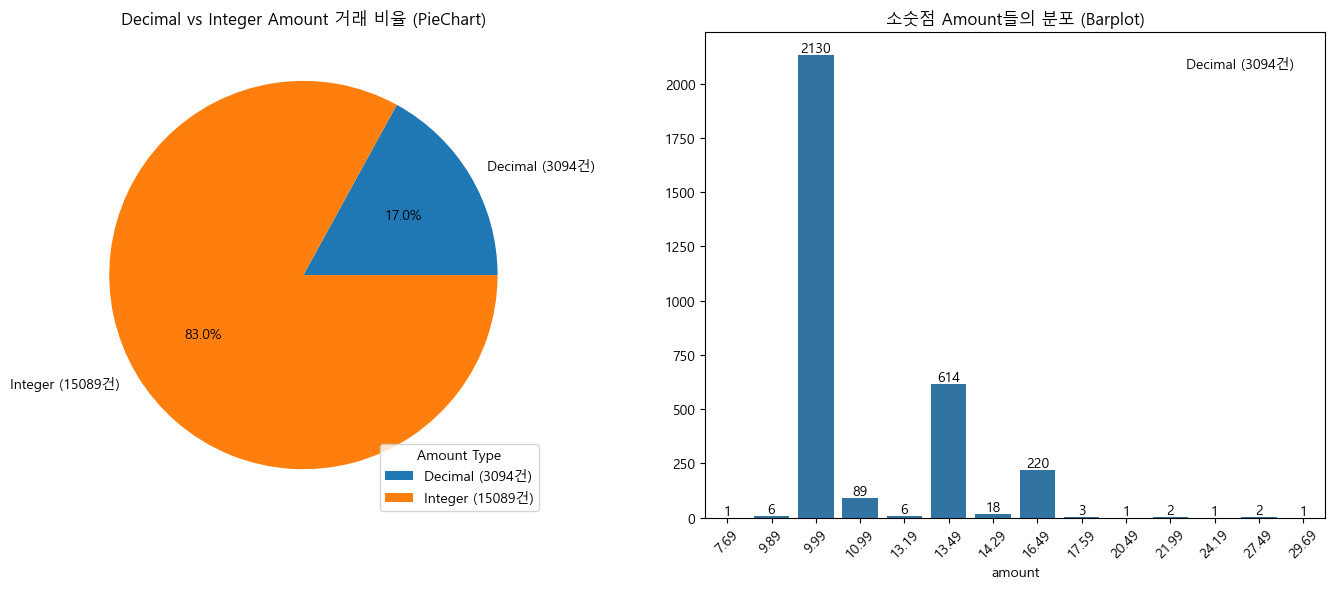

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

is_decimal = membership["amount"].round(2) % 1 != 0
decimal_count = is_decimal.sum()
integer_count = (~is_decimal).sum()

membership_dollar = membership[is_decimal]
counts = membership_dollar["amount"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax_pie = axes[0]
ax_bar = axes[1]

ax_pie.pie(
    [decimal_count, integer_count],
    labels=[f"Decimal ({decimal_count}건)", f"Integer ({integer_count}건)"],
    autopct="%1.1f%%"
)
ax_pie.legend(title="Amount Type", loc="lower right")
ax_pie.set_title("Decimal vs Integer Amount 거래 비율 (PieChart)")

sns.barplot(
    x=counts.index,
    y=counts.values,
    ax=ax_bar
)
ax_bar.text(
    0.95, 0.95,
    f"Decimal ({counts.sum()}건)",
    transform=ax_bar.transAxes,
    ha="right",
    va="top"
)
ax_bar.bar_label(ax_bar.containers[0], fmt="%d")
ax_bar.tick_params(axis="x", labelrotation=45)
ax_bar.set_title("소숫점 Amount들의 분포 (Barplot)")

plt.tight_layout()
plt.show()


In [38]:
membership_decimals = membership[membership["amount"] % 1 != 0]
amount_groupby = membership_decimals.groupby(
	["amount", "concurrent_streams", "payment_device", "billing_method"],
	dropna=False
).size().reset_index(name="count")

amount_groupby

,amount,concurrent_streams,payment_device,billing_method,count
0,7.69,NaN,ios,140,1
1,9.89,1.0,ios,140,6
2,9.99,1.0,ios,140,2130
3,10.99,1.0,ios,140,38
4,10.99,NaN,ios,140,51
5,13.19,1.0,ios,140,2
6,13.19,NaN,ios,140,4
7,13.49,2.0,ios,140,614
8,14.29,1.0,ios,140,11
9,14.29,2.0,ios,140,7


> Concurrent에 맞춰서 plan 추가하기

In [66]:
membership["plan"] = ""

In [69]:
# membership.loc[행 조건, 열 이름] = 값
membership.loc[
	membership["concurrent_streams"] == 1,
	"plan"
] = "Basic"

membership.loc[
	membership["concurrent_streams"] == 2,
	"plan"
] = "Standard"

membership.loc[
	membership["concurrent_streams"] == 4,
	"plan"
] = "Premium"

membership.loc[
	(membership["concurrent_streams"] == 3) | (membership["concurrent_streams"].isna()),
	"plan"
] = "Unknown"

In [70]:
membership.head()

,user_no,product_cd,amount,billing_method,concurrent_streams,promotion_yn,is_churn_prevented,repurchase,payment_device,is_user_verified,gender,age,reg_date,reg_hour,end_date,plan
0,7a6960912bebe03c6e4c770eb1aa91329c3497f18f90ca...,pk_1489,100.00,134,4.0,O,NaN,NaN,pc,Y,F,20.0,2021-03-14,20,2021-04-14,Premium
1,4ec765db76545c1d6dda9f421590bf9d02f584009f8d92...,pk_1487,100.00,190,1.0,O,O,NaN,pc,Y,F,25.0,2021-03-09,14,2021-04-09,Basic
2,4f86d917c53cb6bd8949f76dba7260311e8c1748748a02...,pk_1487,100.00,132,1.0,O,NaN,NaN,android,NaN,F,55.0,2021-03-09,22,2021-04-09,Basic
3,445fb8813626d3d49b94b5be58cd76d80ed31fa94f8372...,pk_1508,9.99,140,1.0,NaN,NaN,O,ios,N,N,40.0,2021-03-09,10,2021-04-10,Basic
4,01b16f9f7ff29b48b1ee0d1a89d1eb9662474e5eedb8c2...,pk_1488,100.00,180,2.0,O,NaN,O,android,N,F,20.0,2021-03-09,2,2021-04-09,Standard
